#house price pediction using machine learning

the objective of thi  sproject is to predict he price of houses based on  multiple factors such sise,loaction and number of rooms.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [16]:
train=pd.read_csv("../data/train.csv")
test=pd.read_csv("../data/test.csv")
print("train shape:",train_data.shape)
print("test shape:",test_data.shape)
train_data.describe()
train_data["SalePrice"].describe()



train shape: (1460, 81)
test shape: (1459, 80)


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [23]:
missing_values=train.isnull().sum()
missing_values=missing_values[missing_values>0].sort_values(ascending=False)
missing_values


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

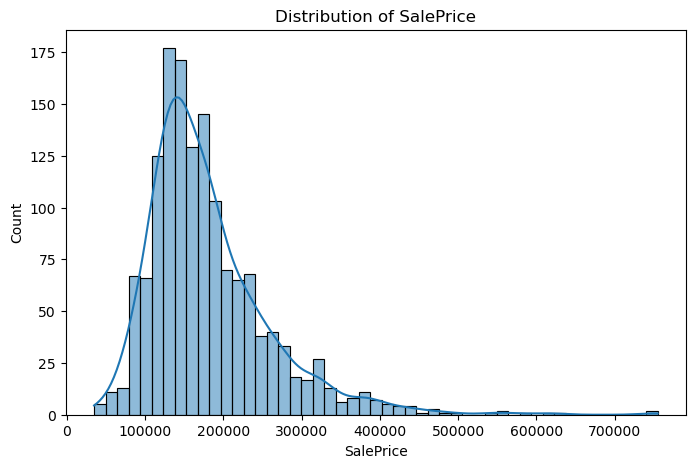

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(train["SalePrice"],kde=True)
plt.title("Distribution of SalePrice")
plt.show()

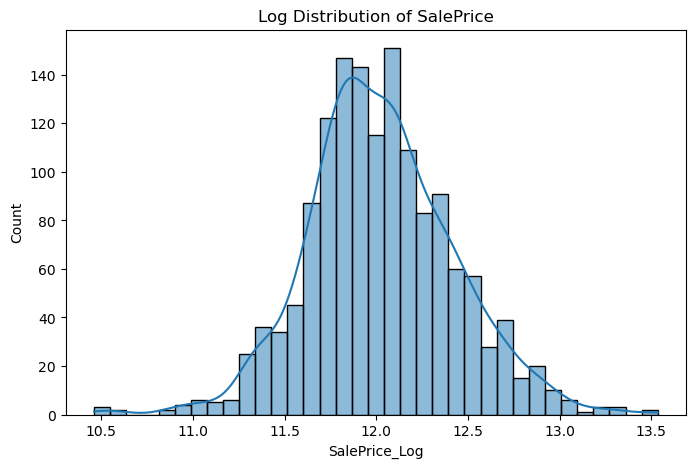

In [27]:
train["SalePrice_Log"]=np.log1p(train["SalePrice"])
plt.figure(figsize=(8, 5))
sns.histplot(train["SalePrice_Log"], kde=True)
plt.title("Log Distribution of SalePrice")
plt.show()


In [28]:
#seperating the target and features 
x=train.drop(["SalePrice","SalePrice_Log","Id"],axis=1)#features
y=train["SalePrice_Log"]#targets which are the predicted house prices 
test_ids = test["Id"]
test_data = test.drop("Id", axis=1)

In [32]:
combined=pd.concat([x,test_data],axis=0)
print(combined.shape)
combined.isnull().sum().sum()

(2919, 79)


np.int64(15707)

In [33]:
for column in combined.columns:
    if combined[column].dtype=="object":
        combined[column]=combined[column].fillna("None")
    else:
        combined[column]=combined[column].fillna(combined[column].median())
        

In [42]:
combined.isnull().sum().sum()

np.int64(0)

In [39]:
combined["TotalSF"]=combined["1stFlrSF"]+combined["2ndFlrSF"]+combined["TotalBsmtSF"]
combined["HouseAge"]=combined["YrSold"]-combined["YearBuilt"]
combined["RemodAge"]=combined["YrSold"]-combined["YearRemodAdd"]
combined["TotalBathrooms"]=(combined["BsmtFullBath"]+combined["FullBath"]+0.5*combined["HalfBath"]+0.5*combined["BsmtHalfBath"])
combined["HasGarage"]=combined["GarageArea"].apply(lambda x:1 if x >0 else 0)
combined["HasBasement"]=combined["TotalBsmtSF"].apply(lambda x:1 if x >0 else 0)

In [45]:
#encoding categorical columns
combined_encoded=pd.get_dummies(combined,drop_first=True)
combined_encoded.shape


(2919, 273)

In [48]:
X_encoded=combined_encoded.iloc[:len(x), :]
test_encoded=combined_encoded.iloc[len(x):, :]
print("X_encoded shape",X_encoded.shape)
print("test_encoded shape",test_encoded.shape)

X_encoded shape (1460, 273)
test_encoded shape (1459, 273)


In [52]:
X_train,X_valid,y_train,y_valid=train_test_split(X_encoded,y,test_size=0.2,random_state=42)
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (1168, 273)
X_valid shape: (292, 273)
y_train shape: (1168,)
y_valid shape: (292,)


In [51]:
y = train["SalePrice_Log"]

print("X_encoded shape:", X_encoded.shape)
print("y shape:", y.shape)

X_encoded shape: (1460, 273)
y shape: (1460,)


In [55]:
ridge_model=Ridge(alpha=10)
ridge_model.fit(X_train,y_train)
ridge_predictions = ridge_model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, ridge_predictions))
r2 = r2_score(y_valid, ridge_predictions)
print("Ridge Regression RMSE:", rmse)
print("Ridge Regression R2:", r2)

Ridge Regression RMSE: 0.1388421755008473
Ridge Regression R2: 0.8966987429649083


In [67]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10),
    "Lasso Regression": Lasso(alpha=0.01, max_iter=10000),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    print("Training:", name)
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_valid)
    
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    mae = mean_absolute_error(y_valid, predictions)
    r2 = r2_score(y_valid, predictions)
    
    results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df

Training: Linear Regression
Training: Ridge Regression
Training: Lasso Regression
Training: Random Forest
Training: Gradient Boosting


,RMSE,MAE,R2
Gradient Boosting,0.135177,0.089593,0.902080
Ridge Regression,0.138842,0.095900,0.896699
Random Forest,0.149842,0.099499,0.879682
Lasso Regression,0.153605,0.106143,0.873564
Linear Regression,0.173662,0.095795,0.838389


In [68]:
best_model = GradientBoostingRegressor(random_state=42)

best_model.fit(X_encoded, y)

test_predictions_log = best_model.predict(test_encoded)

test_predictions = np.expm1(test_predictions_log)

final_predictions = pd.DataFrame({
    "Id": test_ids,
    "PredictedSalePrice": test_predictions
})

final_predictions.head()

,Id,PredictedSalePrice
0,1461,119598.449058
1,1462,161713.833818
2,1463,183448.174305
3,1464,185559.824546
4,1465,190839.505437


In [69]:
final_predictions.to_csv("../outputs/final_predictions.csv", index=False)


In [70]:
## Conclusion

In this project, I built a machine learning regression model to predict house prices. The dataset was cleaned, missing values were handled, new features were engineered, and categorical variables were encoded.

Several regression models were compared, including Linear Regression, Ridge Regression, Lasso Regression, Random Forest, and Gradient Boosting. Gradient Boosting achieved the best validation performance, with the lowest RMSE and highest R² score.

The final Gradient Boosting model was trained on the full training dataset and used to generate predicted house prices for the test dataset.

SyntaxError: invalid character '²' (U+00B2) (2379425604.py, line 5)

In [71]:
import os
print(os.getcwd())

C:\Users\dohai\house price prediction\notebooks
